In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split



In [2]:
#load predictions
val_results_df = pd.read_csv("/zhome/d0/a/221493/thesis/results/device_classifier/densenet/val_device_predictions.csv")
train_results_df = pd.read_csv("/zhome/d0/a/221493/thesis/results/device_classifier/densenet/train_device_predictions.csv")

In [3]:
# Add this after loading the CSVs
_, cal_df = train_test_split(
    train_results_df, test_size=0.1, random_state=42,
    stratify=train_results_df["true"]
)


In [4]:
# See columns
print(val_results_df.columns)

Index(['path', 'prob', 'true', 'pred', 'correct', 'margin'], dtype='object')


In [5]:
val_results_df

,path,prob,true,pred,correct,margin
0,CheXpert-v1.0-small/train/patient00005/study1/...,0.994038,1.0,1,1,0.019858
1,CheXpert-v1.0-small/train/patient00005/study1/...,0.999653,1.0,1,1,0.025473
2,CheXpert-v1.0-small/train/patient00008/study1/...,0.996491,1.0,1,1,0.022311
3,CheXpert-v1.0-small/train/patient00008/study2/...,0.998403,1.0,1,1,0.024223
4,CheXpert-v1.0-small/train/patient00012/study3/...,0.999744,1.0,1,1,0.025564
...,...,...,...,...,...,...
34850,CheXpert-v1.0-small/train/patient64519/study1/...,0.989638,1.0,1,1,0.015458
34851,CheXpert-v1.0-small/train/patient64522/study1/...,0.994332,0.0,1,0,0.020152
34852,CheXpert-v1.0-small/train/patient64527/study2/...,0.999940,1.0,1,1,0.025760
34853,CheXpert-v1.0-small/train/patient64527/study1/...,0.995640,1.0,1,1,0.021460


In [6]:
# calculate AUC using the columns: 'true' (true labels) and 'Predicted Probability' (predicted probabilities)
auc = roc_auc_score(val_results_df['true'], val_results_df['prob'])
print(f"AUC: {auc:.4f}")

AUC: 0.7877


In [7]:
def find_optimal_threshold(df):

    fpr, tpr, thresholds = roc_curve(
        df["true"],
        df["prob"]
    )

    auc = roc_auc_score(
        df["true"],
        df["prob"]
    )

    thresh = thresholds[np.argmax(tpr - fpr)]

    return thresh, auc


# apply optimal threshold
optimal_threshold, auc = find_optimal_threshold(cal_df)
print(f"Optimal Threshold: {optimal_threshold:.4f}, AUC: {auc:.4f}")

Optimal Threshold: 0.9954, AUC: 0.9462


In [8]:
def find_optimal_threshold_f1(df):
    from sklearn.metrics import f1_score
    _, _, thresholds = roc_curve(df["true"], df["prob"])
    f1s = [f1_score(df["true"], (df["prob"] > t).astype(int), 
                    zero_division=0) for t in thresholds]
    return thresholds[np.argmax(f1s)]

optimal_threshold_f1 = find_optimal_threshold_f1(cal_df)
print(f"Optimal Threshold (F1): {optimal_threshold_f1:.4f}")

Optimal Threshold (F1): 0.9742


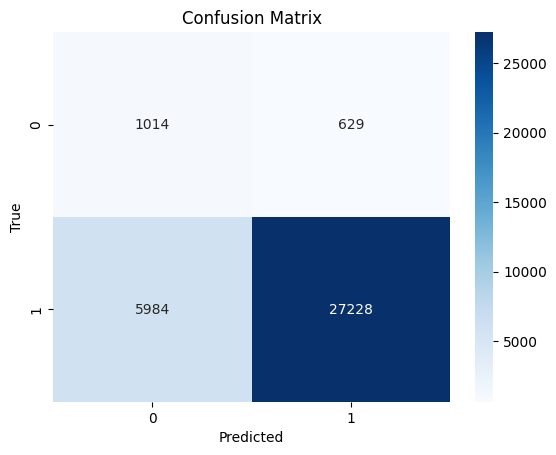

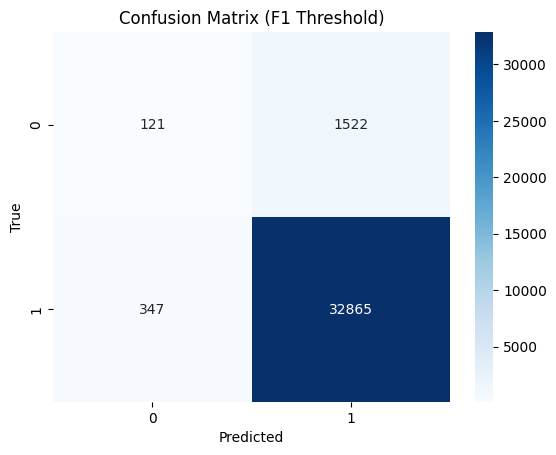

Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

         0.0       0.26      0.07      0.11      1643
         1.0       0.96      0.99      0.97     33212

    accuracy                           0.95     34855
   macro avg       0.61      0.53      0.54     34855
weighted avg       0.92      0.95      0.93     34855

Classification Report (F1 Threshold):
              precision    recall  f1-score   support

         0.0       0.26      0.07      0.11      1643
         1.0       0.96      0.99      0.97     33212

    accuracy                           0.95     34855
   macro avg       0.61      0.53      0.54     34855
weighted avg       0.92      0.95      0.93     34855



In [9]:
# Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns   
cm = confusion_matrix(val_results_df['true'], val_results_df['prob'] > optimal_threshold)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()  


# Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns   
cm_f1 = confusion_matrix(val_results_df['true'], val_results_df['prob'] > optimal_threshold_f1)
sns.heatmap(cm_f1, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (F1 Threshold)')
plt.show()  

#print cm and classification report
print("Classification Report (Optimal Threshold):")
print(classification_report(val_results_df['true'], val_results_df['pred'] > optimal_threshold))
print("Classification Report (F1 Threshold):")
print(classification_report(val_results_df['true'], val_results_df['pred'] > optimal_threshold_f1))

In [10]:
# Use & instead of 'and' and wrap conditions in ()
pos_mask = (val_results_df['prob'] > optimal_threshold_f1) & (val_results_df['true'] == 1)
positive_predictions = val_results_df[pos_mask].head(10)

neg_mask = (val_results_df['prob'] <= optimal_threshold_f1) & (val_results_df['true'] == 0)
negative_predictions = val_results_df[neg_mask].head(10)

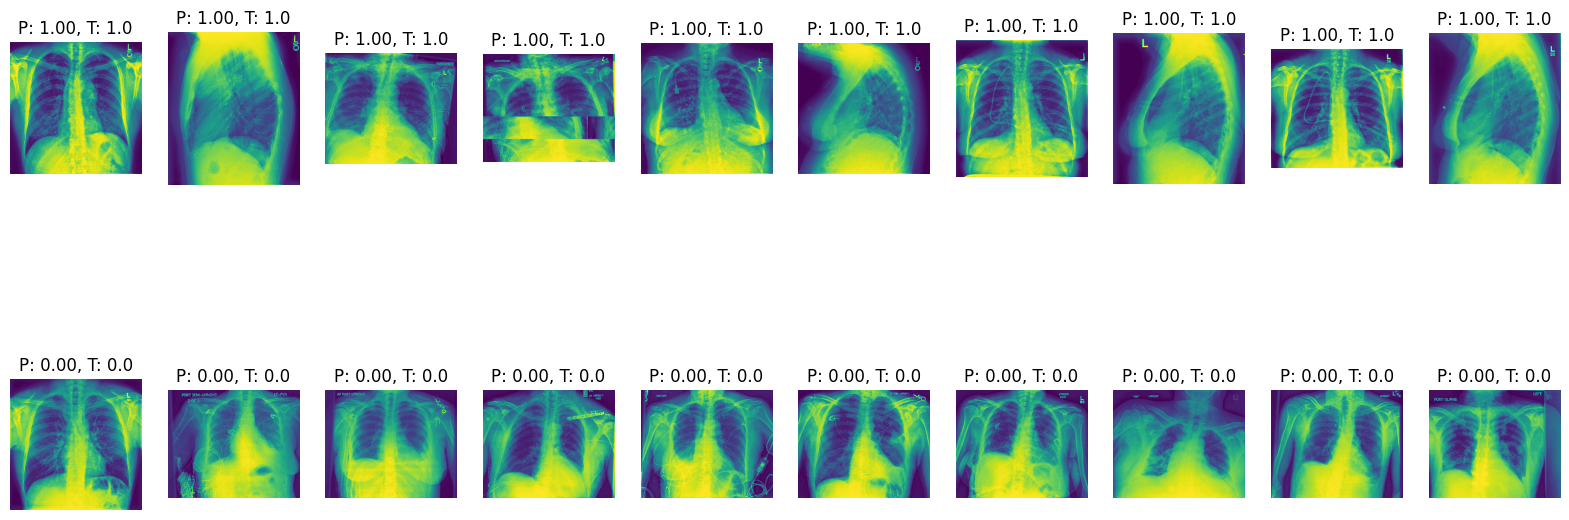

In [11]:

# To avoid repeating the base_path logic, you can define a helper
def plot_preds(df, ax_row):
    for i, (idx, row) in enumerate(df.iterrows()):
        full_path = f"/zhome/d0/a/221493/thesis/data/{row['path']}"
        img = plt.imread(full_path)
        ax_row[i].imshow(img)
        ax_row[i].set_title(f"P: {row['pred']:.2f}, T: {row['true']}")
        ax_row[i].axis('off')

fig, axes = plt.subplots(2, 10, figsize=(20, 8))
plot_preds(positive_predictions, axes[0])
plot_preds(negative_predictions, axes[1])
plt.show()

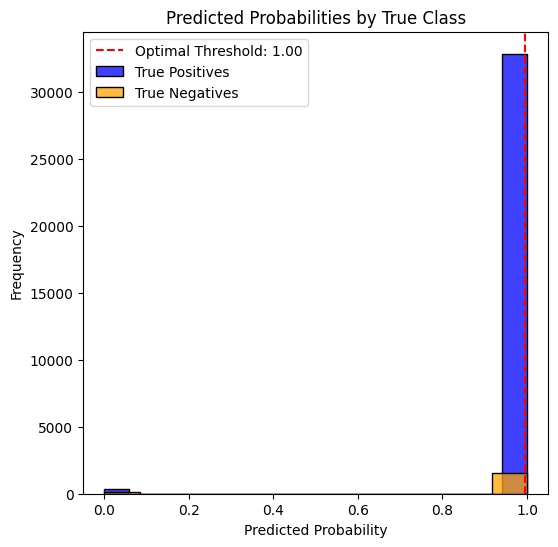

In [14]:
# plot histograms of predicted probabilities for true positives and true negatives
plt.figure(figsize=(6, 6))
sns.histplot(val_results_df[val_results_df['true'] == 1]['pred'], color='blue', label='True Positives')
sns.histplot(val_results_df[val_results_df['true'] == 0]['pred'], color='orange', label='True Negatives')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold: {optimal_threshold:.2f}')
plt.title('Predicted Probabilities by True Class')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

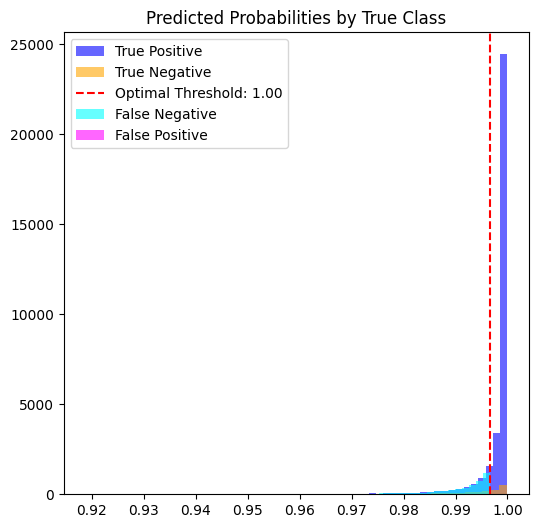

In [118]:
import matplotlib.pyplot as plt
import pandas as pd

val_df = pd.read_csv("/zhome/d0/a/221493/thesis/results/device_classifier/densenet/val_device_predictions.csv")

plt.figure(figsize=(6, 6))
plt.hist(val_df[val_df["true"]==1]["prob"], bins=50, alpha=0.6, label="True Positive", color="blue")
plt.hist(val_df[val_df["true"]==0]["prob"], bins=50, alpha=0.6, label="True Negative", color="orange")
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold: {optimal_threshold:.2f}')
# now false positives and false negatives
plt.hist(val_df[(val_df["true"]==1) & (val_df["prob"] <= optimal_threshold)]["prob"], bins=50, alpha=0.6, label="False Negative", color="cyan")
plt.hist(val_df[(val_df["true"]==0) & (val_df["prob"] > optimal_threshold)]["prob"], bins=50, alpha=0.6, label="False Positive", color="magenta")
plt.legend()
plt.title("Predicted Probabilities by True Class")
plt.savefig("prob_hist.png")